In [2]:
import os
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import pandas as pd
import anndata as ad
import scipy
from plotnine import (
    ggplot, aes, geom_histogram, scale_x_continuous, facet_wrap, geom_vline,
    theme, element_text, labs, ylim
)

In [3]:
## Extract the files from directory

os.chdir("/work/ABG/mkapoor/PRRSV/PRRSV_cellranger_v97/")
sample_dirs = [d for d in os.listdir() if d.startswith('Sample_') and os.path.isdir(d)]
cellranger_output =  []
for sample_dir in sample_dirs:
    files = os.listdir(sample_dir)
    sample_dir_path = os.path.join(sample_dir, f"{sample_dir}_output", "outs")
    if os.path.exists(sample_dir_path):
        files = os.listdir(sample_dir_path)
        filtered_files = [os.path.join(sample_dir_path, f) for f in files if f.endswith('filtered_feature_bc_matrix.h5')]
        cellranger_output.extend(filtered_files)

In [4]:
#add treatment info to the data samples
control = [101,28,3,96]
extinct = [35,64]
persistent = [4, 19, 33, 104, 97, 5, 27, 66, 98, 102]

#add sex info
male = [101, 3, 35, 64, 4, 19, 33, 5, 66, 102]
female = [28, 96, 104, 97, 27, 98]

#add sow info
sow_1=[3,4,5]
sow_2 = [19,27,28]
sow_3 = [33,35]
sow_5 = [64,66]
sow_7 = [96,97,98]
sow_8 = [101,102,104]

mito_genes = pd.read_csv('/work/ABG/mkapoor/PRRSV/PRRSV_cellranger_v97/mitogene_id.csv')
# create function to load data
def load_cr(file):
    sample = file.split('_')[1].split('/')[0]
    sample_number = int(sample)  # Convert to integer for comparison
    file = sc.read_10x_h5(file)
    file.obs['Sample'] = sample
    file.obs['Timepoint'] = '84_dpi'
    
    if sample_number in control:
        file.obs['Treatment'] = 'control'
    elif sample_number in extinct:
        file.obs['Treatment'] = 'extinct'
    else:
        file.obs['Treatment'] = 'persistent'
    
    if sample_number in male:
        file.obs['Sex'] = 'Male'
    elif sample_number in female:
        file.obs['Sex'] = 'Female'
    else:
        print('None')
    
    if sample_number in sow_1:
        file.obs['Sow'] = 'Sow_1'
    elif sample_number in sow_2:
        file.obs['Sow'] = 'Sow_2'
    elif sample_number in sow_3:
        file.obs['Sow'] = 'Sow_3'
    elif sample_number in sow_5:
        file.obs['Sow'] = 'Sow_5'
    elif sample_number in sow_7:
        file.obs['Sow'] = 'Sow_7'
    elif sample_number in sow_8:
        file.obs['Sow'] = 'Sow_8'
    else:
        print('None')
    
    file.var['Duplicated'] = file.var.duplicated('gene_ids') | file.var.duplicated('gene_ids', keep='last')
    file.var['Name'] = file.var.apply(lambda row: row['gene_ids'].split('_')[1] if row['Duplicated'] else row['gene_ids'].split('_')[0], axis=1)
    file.var['Mitochondrial'] = file.var['Name'].isin(mito_genes['x'])
    
    return file

In [5]:
adata_list = []

for file in cellranger_output:
    adata = load_cr(file)
    adata_list.append(adata)


In [6]:
combined_adata = adata_list[0].concatenate(adata_list[1:], batch_key='Sample', batch_categories=[file.split('_')[1].split('/')[0] for file in cellranger_output])

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/578559938.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html


In [7]:
combined_adata


AnnData object with n_obs × n_vars = 111378 × 25880
    obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow'
    var: 'gene_ids', 'feature_types', 'genome', 'Duplicated', 'Name', 'Mitochondrial'

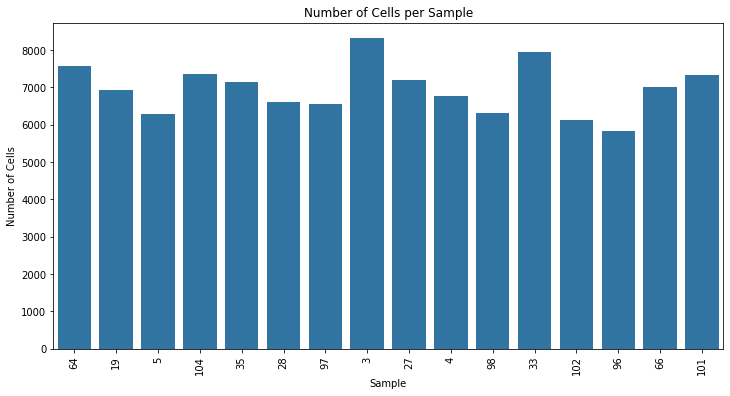

In [8]:
sample_counts = combined_adata.obs['Sample'].value_counts()

# Convert to DataFrame for easier plotting
sample_counts_df = sample_counts.reset_index()
sample_counts_df.columns = ['Sample', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sample_counts_df, x='Sample', y='Cell Count')
plt.xlabel('Sample')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per Sample')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

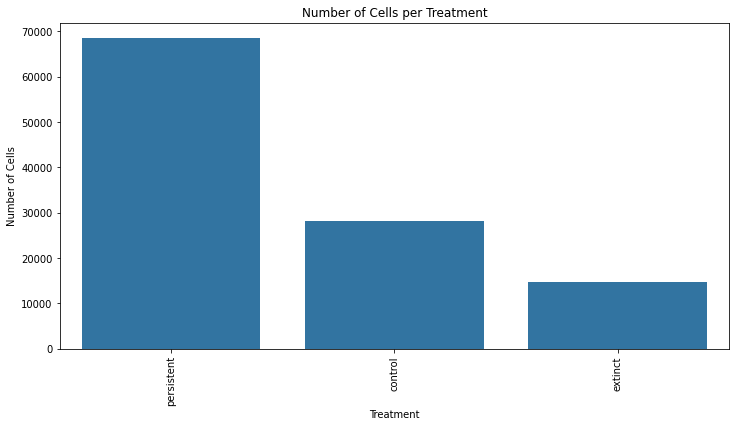

In [9]:
Treatment_counts = combined_adata.obs['Treatment'].value_counts()

# Convert to DataFrame for easier plotting
Treatment_counts_df = Treatment_counts.reset_index()
Treatment_counts_df.columns = ['Treatment', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=Treatment_counts_df, x='Treatment', y='Cell Count')
plt.xlabel('Treatment')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per Treatment')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

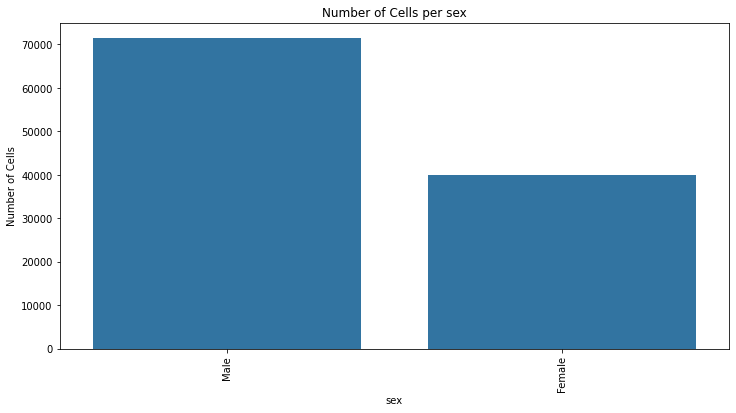

In [11]:
sex_counts = combined_adata.obs['Sex'].value_counts()

# Convert to DataFrame for easier plotting
sex_counts_df = sex_counts.reset_index()
sex_counts_df.columns = ['sex', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sex_counts_df, x='sex', y='Cell Count')
plt.xlabel('sex')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per sex')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

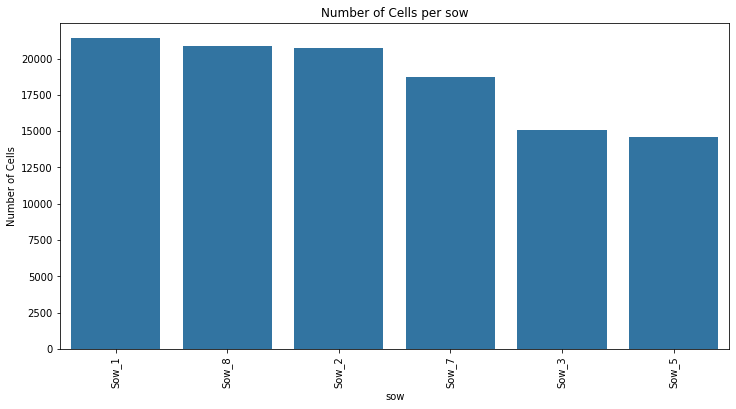

In [12]:
sow_counts = combined_adata.obs['Sow'].value_counts()

# Convert to DataFrame for easier plotting
sow_counts_df = sow_counts.reset_index()
sow_counts_df.columns = ['sow', 'Cell Count']
plt.figure(figsize=(12, 6))
sns.barplot(data=sow_counts_df, x='sow', y='Cell Count')
plt.xlabel('sow')
plt.ylabel('Number of Cells')
plt.title('Number of Cells per sow')
plt.xticks(rotation=90)  # Rotate x-axis labels if needed
plt.show()

In [13]:
combined_adata.var['mt'] = combined_adata.var['Mitochondrial']
sc.pp.calculate_qc_metrics(combined_adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [14]:
combined_adata.obs

,Sample,Timepoint,Treatment,Sex,Sow,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt
AAACCCACAAGCCTGC-1-64,64,84_dpi,extinct,Male,Sow_5,2320,6364.0,178.0,2.796983
AAACCCATCACCATAG-1-64,64,84_dpi,extinct,Male,Sow_5,157,10125.0,14.0,0.138272
AAACGAAAGACGCCAA-1-64,64,84_dpi,extinct,Male,Sow_5,1600,4454.0,102.0,2.290076
AAACGAAAGCGATGAC-1-64,64,84_dpi,extinct,Male,Sow_5,4601,25495.0,1707.0,6.695431
AAACGAAAGGTAACTA-1-64,64,84_dpi,extinct,Male,Sow_5,96,4921.0,1.0,0.020321
...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCAATCTG-1-101,101,84_dpi,control,Male,Sow_8,2439,6777.0,143.0,2.110078
TTTGTTGGTTCCGCAG-1-101,101,84_dpi,control,Male,Sow_8,1424,2940.0,85.0,2.891156
TTTGTTGTCATTCACT-1-101,101,84_dpi,control,Male,Sow_8,2175,5612.0,91.0,1.621525
TTTGTTGTCCCAGGAC-1-101,101,84_dpi,control,Male,Sow_8,2532,6673.0,109.0,1.633448


In [15]:
combined_adata.var

,gene_ids,feature_types,genome,Duplicated,Name,Mitochondrial,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
TBP,ENSSSCG00000037372,Gene Expression,ssc97,False,ENSSSCG00000037372,False,False,1664,0.016368,98.505989,1823.0
PSMB1,ENSSSCG00000027257,Gene Expression,ssc97,False,ENSSSCG00000027257,False,False,61878,1.147605,44.443247,127818.0
FAM120B,ENSSSCG00000029697,Gene Expression,ssc97,False,ENSSSCG00000029697,False,False,23864,0.299960,78.573866,33409.0
ENSSSCG00000027274,ENSSSCG00000027274,Gene Expression,ssc97,False,ENSSSCG00000027274,False,False,17,0.000153,99.984737,17.0
DLL1,ENSSSCG00000027726,Gene Expression,ssc97,False,ENSSSCG00000027726,False,False,107,0.001095,99.903931,122.0
...,...,...,...,...,...,...,...,...,...,...,...
ENSSSCG00000040882,ENSSSCG00000040882,Gene Expression,ssc97,False,ENSSSCG00000040882,False,False,0,0.000000,100.000000,0.0
ENSSSCG00000036366,ENSSSCG00000036366,Gene Expression,ssc97,False,ENSSSCG00000036366,False,False,0,0.000000,100.000000,0.0
MIR6782_37644,ENSSSCG00000037644,Gene Expression,ssc97,False,ENSSSCG00000037644,False,False,17,0.000153,99.984737,17.0
5_8S_rRNA_36779,ENSSSCG00000036779,Gene Expression,ssc97,False,ENSSSCG00000036779,False,False,0,0.000000,100.000000,0.0


In [16]:
###QC steps###
qc_data = combined_adata.obs.copy()

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/3017116752.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/3017116752.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/3017116752.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



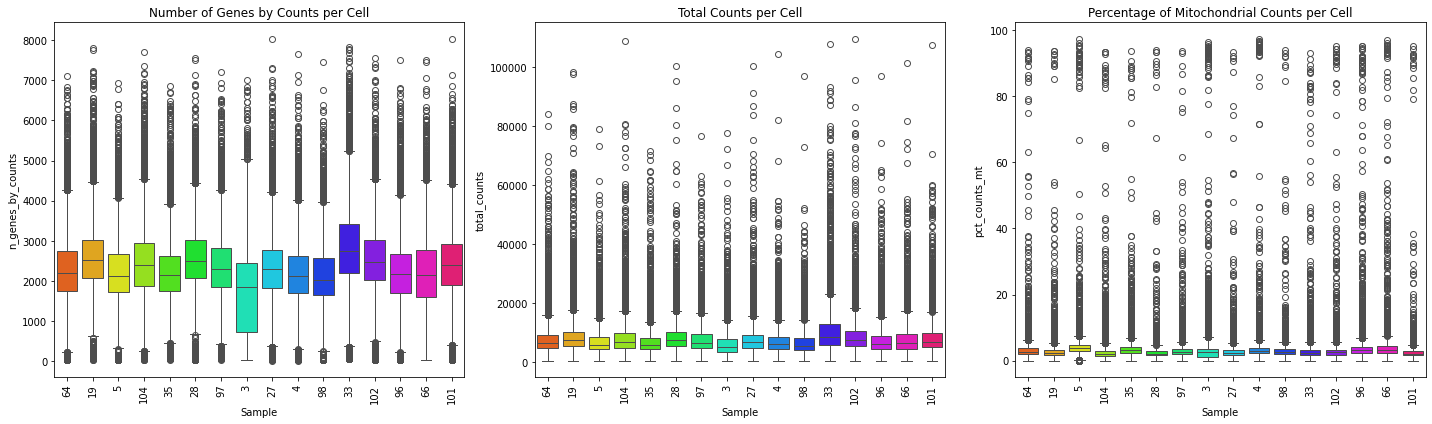

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_qc_parameters(qc_data):
    # Get unique samples and define a color palette
    samples = qc_data['Sample'].unique()
    num_samples = len(samples)
    palette = sns.color_palette("hsv", num_samples)  # Color palette with a distinct color for each sample
    
    plt.figure(figsize=(20, 6))

    # Plot n_genes_by_counts
    plt.subplot(1, 3, 1)
    sns.boxplot(data=qc_data, x='Sample', y='n_genes_by_counts', palette=palette)
    plt.title('Number of Genes by Counts per Cell')
    plt.xticks(rotation=90)

    # Plot total_counts
    plt.subplot(1, 3, 2)
    sns.boxplot(data=qc_data, x='Sample', y='total_counts', palette=palette)
    plt.title('Total Counts per Cell')
    plt.xticks(rotation=90)

    # Plot pct_counts_mt
    plt.subplot(1, 3, 3)
    sns.boxplot(data=qc_data, x='Sample', y='pct_counts_mt', palette=palette)
    plt.title('Percentage of Mitochondrial Counts per Cell')
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

# Call the function to plot the QC parameters
plot_qc_parameters(qc_data)


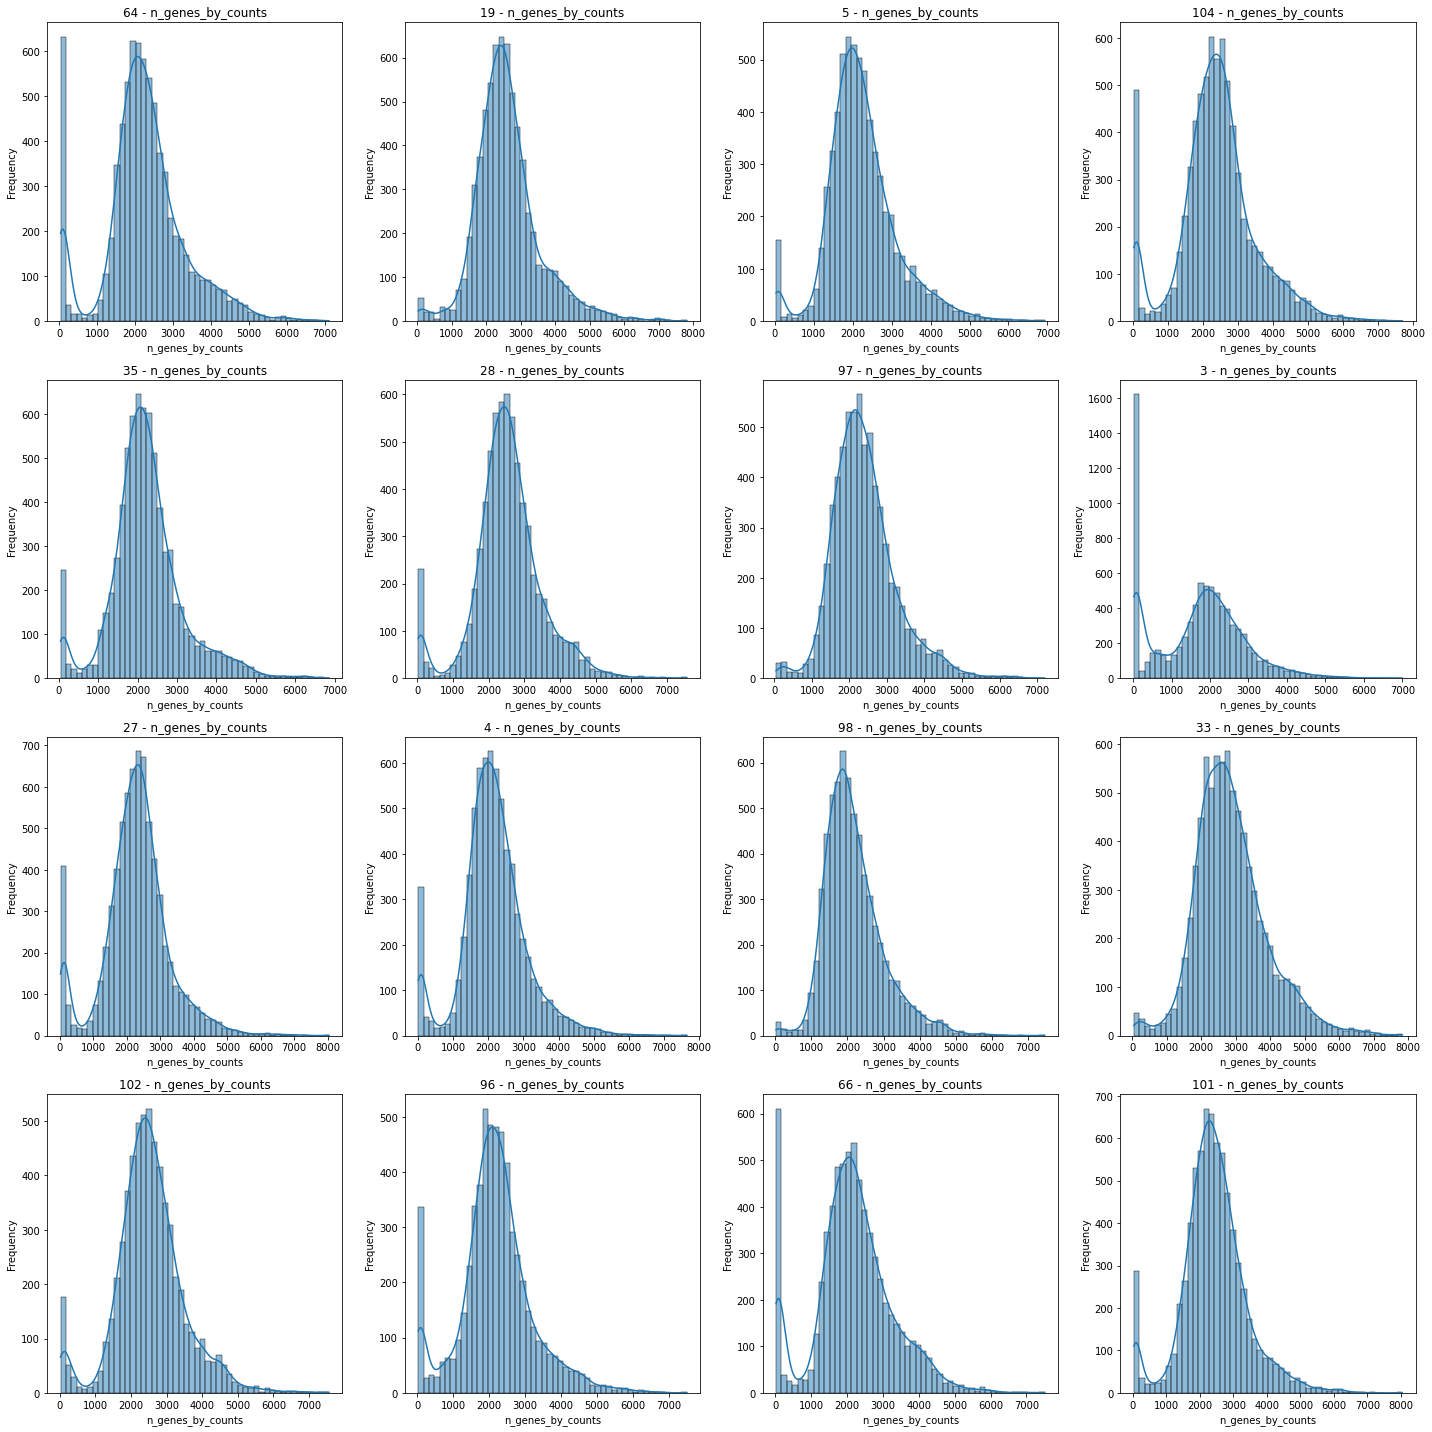

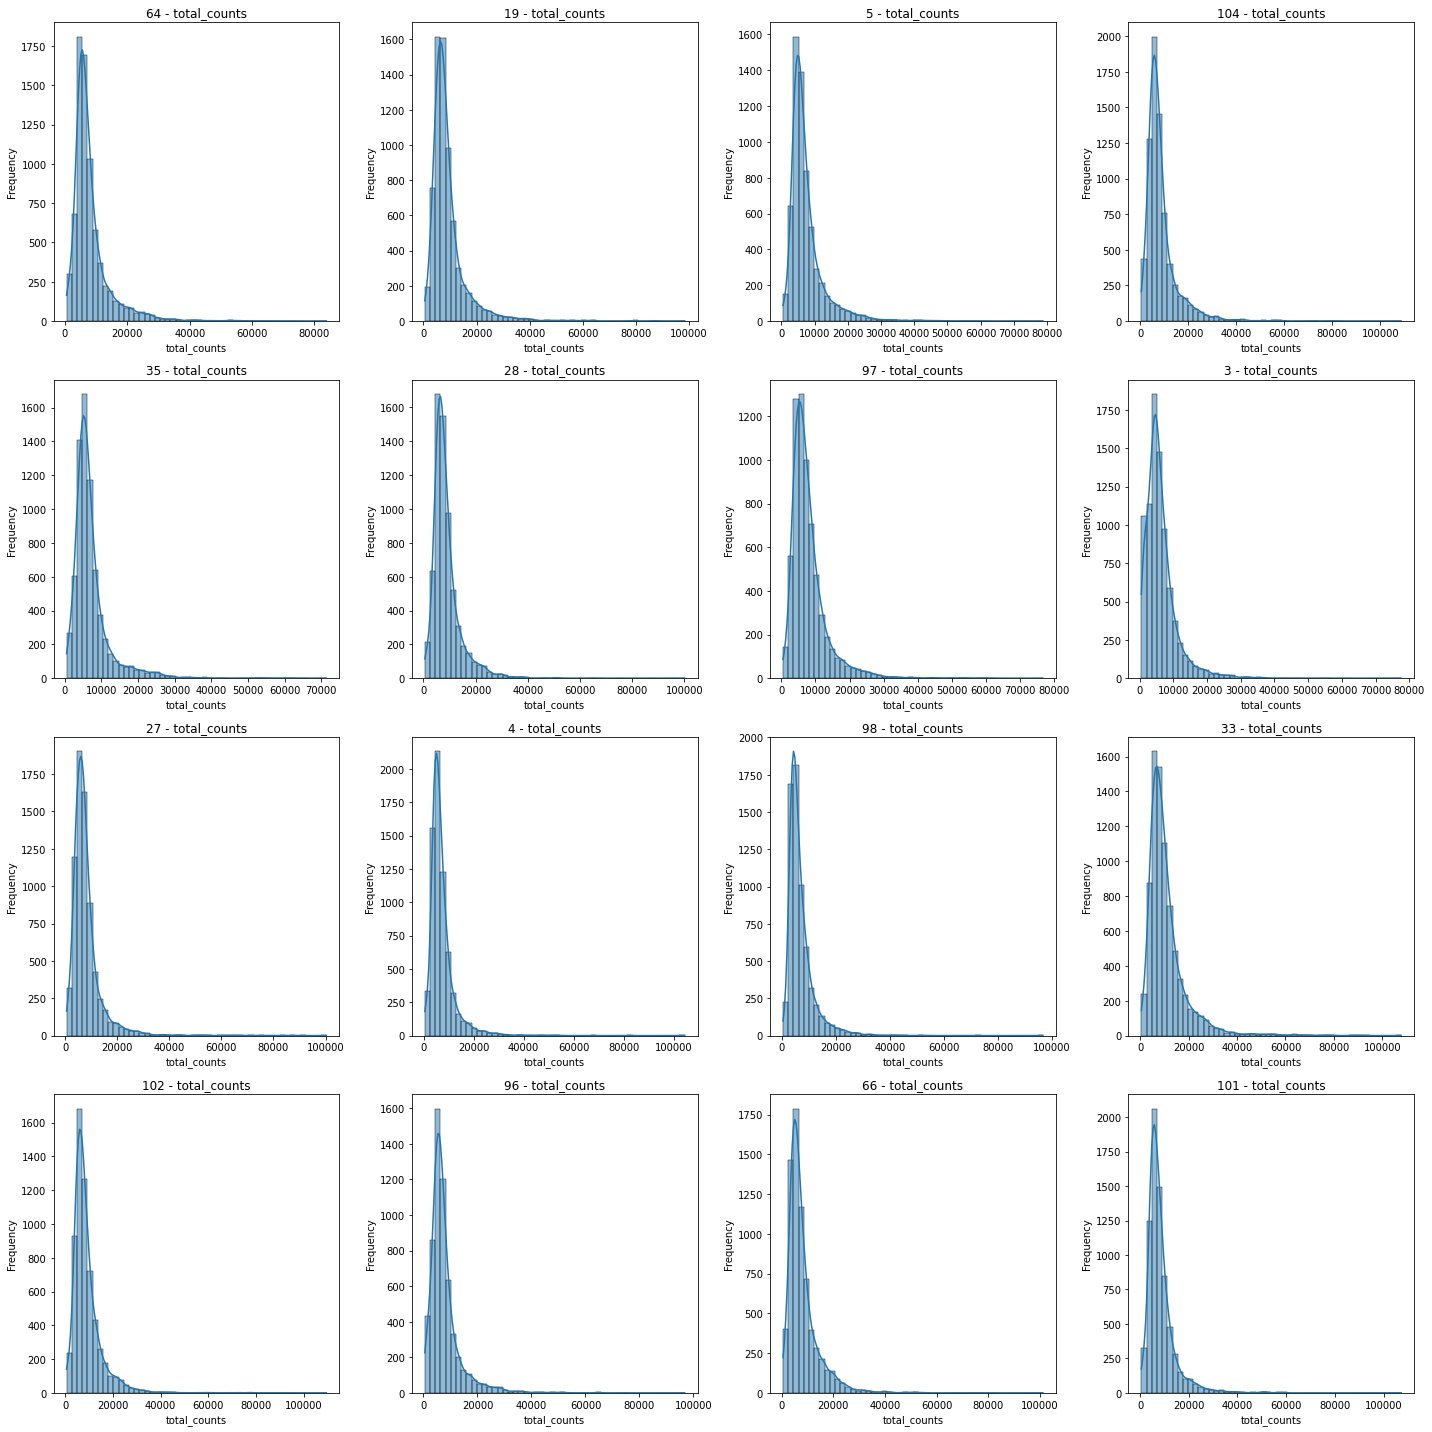

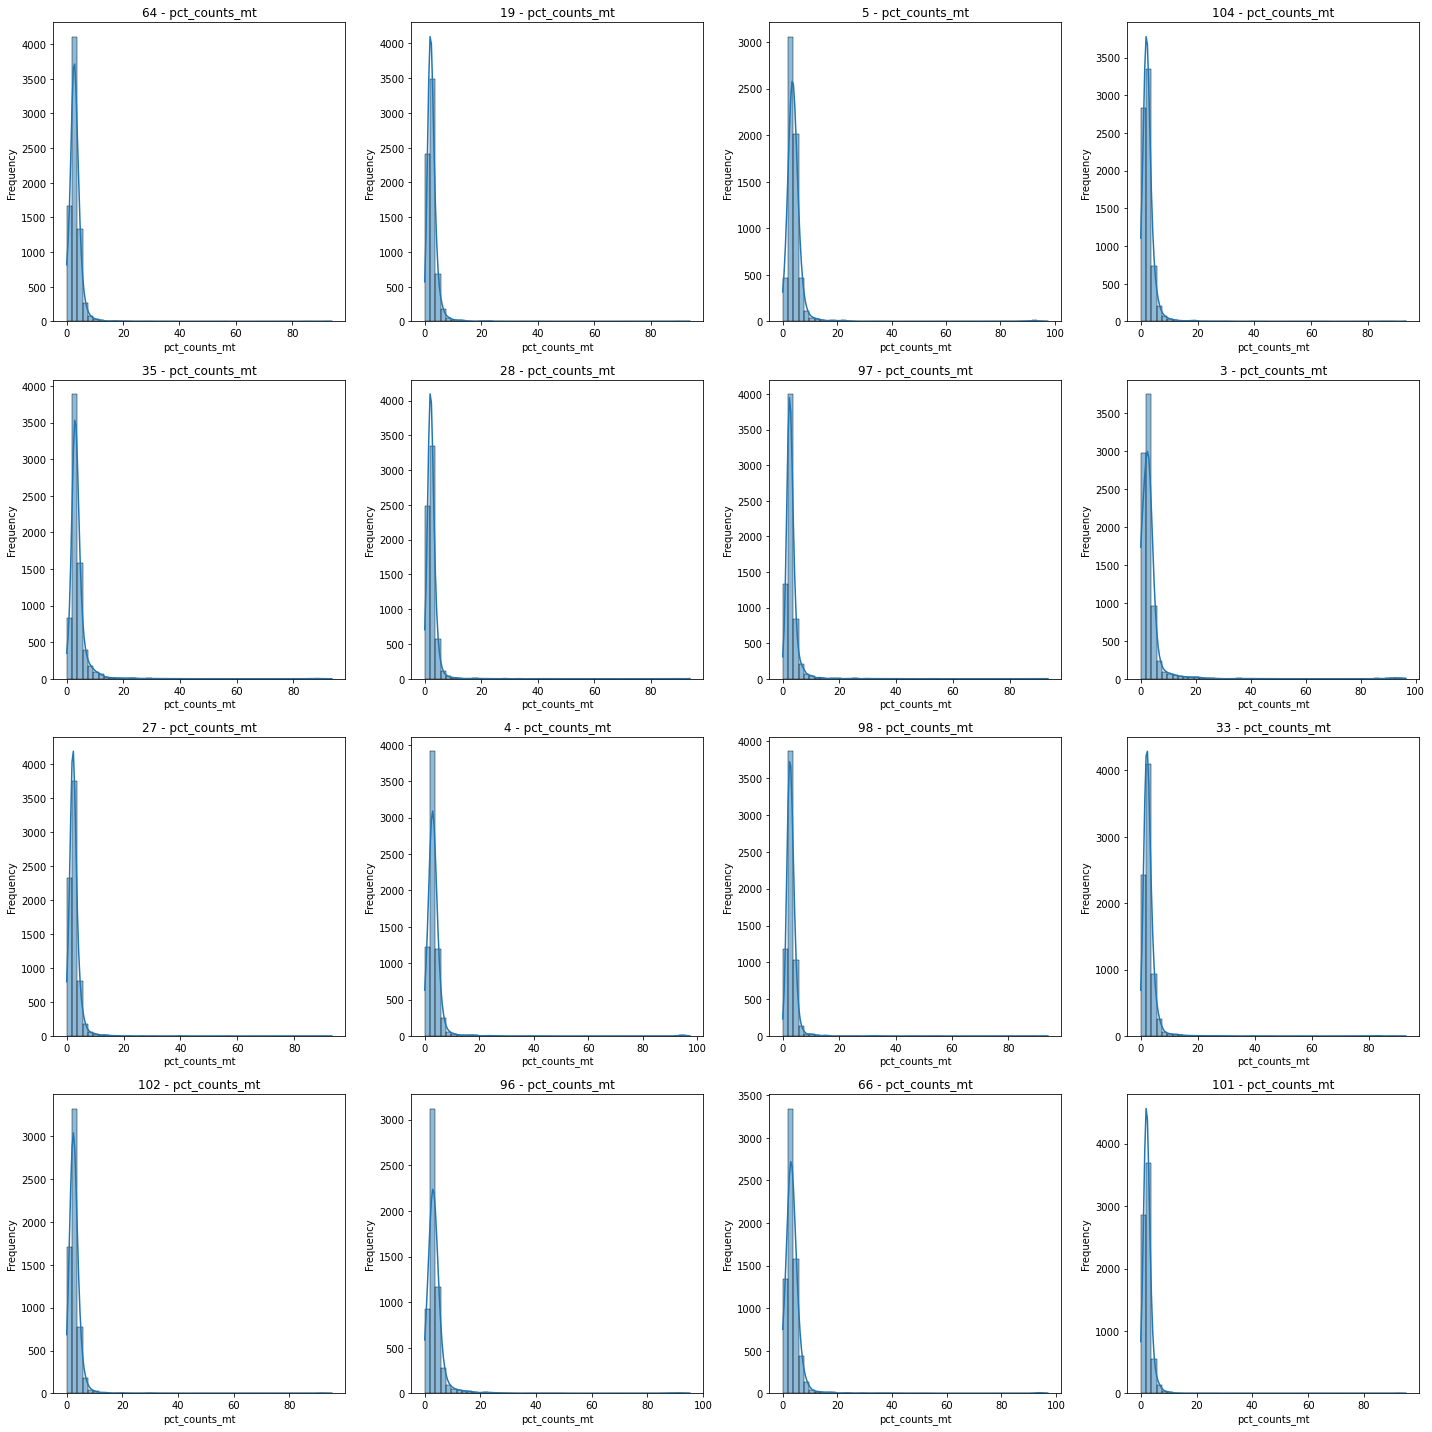

In [18]:
def plot_histograms(qc_data, metric):
    samples = qc_data['Sample'].unique()
    num_samples = len(samples)
    num_cols = 4
    num_rows = (num_samples + num_cols - 1) // num_cols
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
    axes = axes.flatten()
    
    for i, sample in enumerate(samples):
        ax = axes[i]
        sns.histplot(qc_data[qc_data['Sample'] == sample][metric], bins=50, kde=True, ax=ax)
        ax.set_title(f'{sample} - {metric}')
        ax.set_xlabel(metric)
        ax.set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()

# Plot histograms for each QC metric
metrics = ['n_genes_by_counts', 'total_counts','pct_counts_mt']
for metric in metrics:
    plot_histograms(qc_data, metric)

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/228206168.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



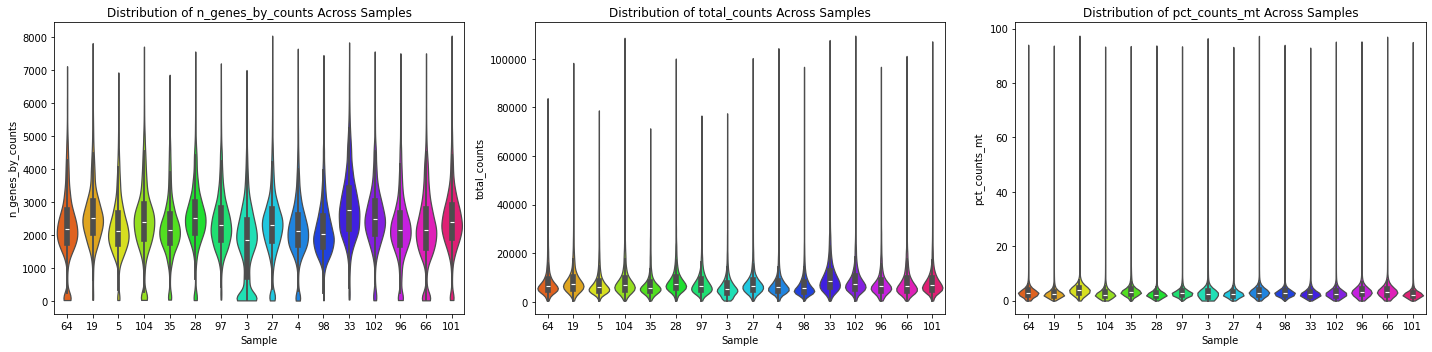

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_violin_plots(qc_data, metrics):
    samples = qc_data['Sample'].unique()
    num_samples = len(samples)
    num_metrics = len(metrics)
    num_cols = 3  
    num_rows = (num_metrics + num_cols - 1) // num_cols
    
    # Define a color palette with a distinct color for each sample
    palette = sns.color_palette("hsv", num_samples)
    
    # Create a figure with subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, num_rows * 5))
    axes = axes.flatten()  # Flatten to easily index them
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        # Use seaborn's violinplot to plot each metric, with colors defined by the palette
        sns.violinplot(x='Sample', y=metric, data=qc_data, ax=ax, palette=palette, cut=0)
        ax.set_title(f'Distribution of {metric} Across Samples')
        ax.set_xlabel('Sample')
        ax.set_ylabel(metric)
    
    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()

# List of QC metrics to plot
metrics = ['n_genes_by_counts', 'total_counts', 'pct_counts_mt']
plot_violin_plots(qc_data, metrics)


/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/1219150481.py:11: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 553 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 32 rows containing missing values.


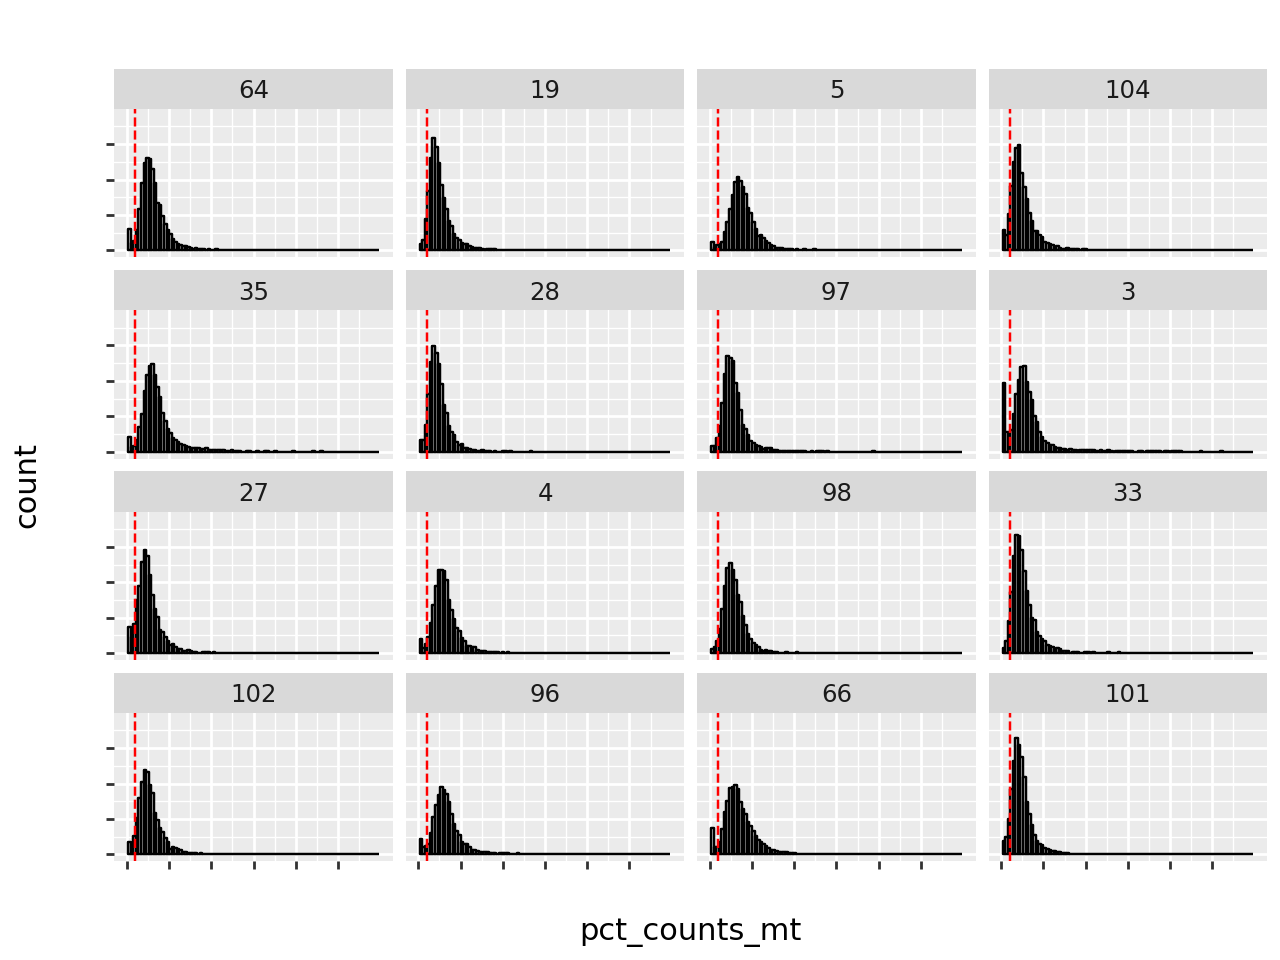

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/1219150481.py:23: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 72108 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 45 rows containing missing values.


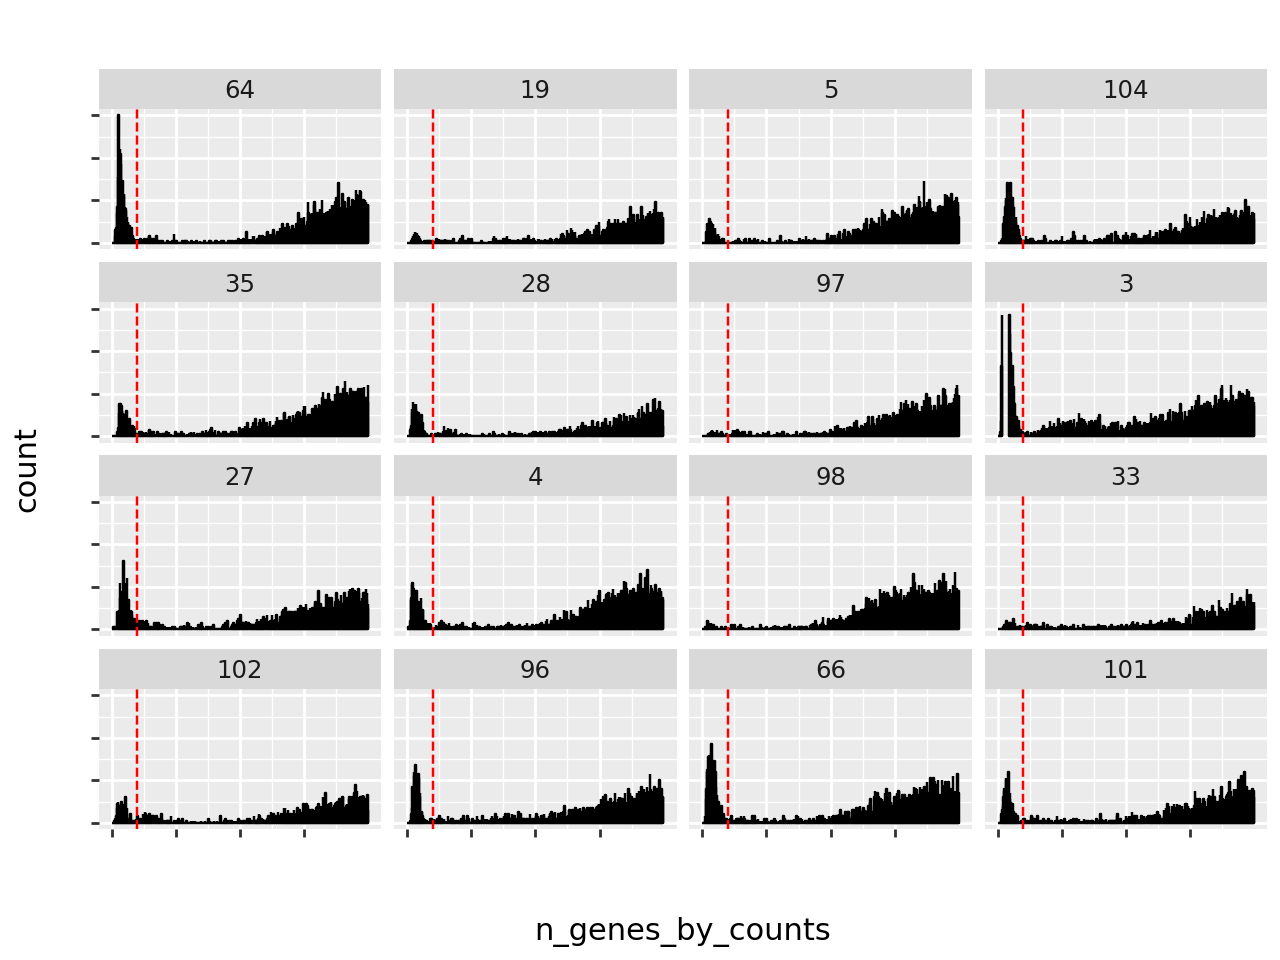

/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/1219150481.py:34: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:284: PlotnineWarning: stat_bin : Removed 78783 rows containing non-finite values.
/home/mkapoor/.local/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 32 rows containing missing values.


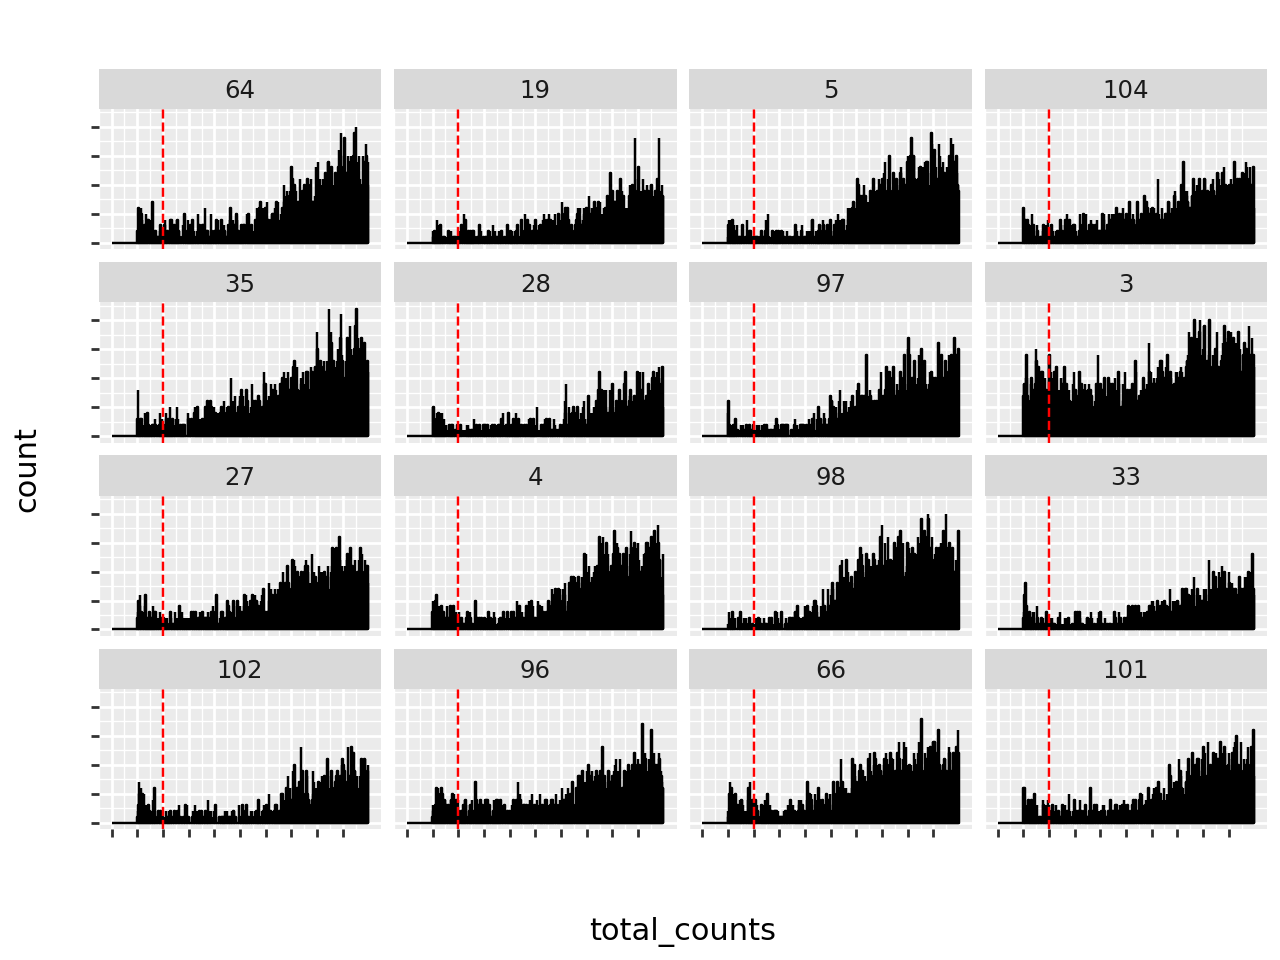

In [20]:
def plot_data(df):
    # Percent Mitochondrial Reads Plot
    p1 = (ggplot(df, aes(x='pct_counts_mt'))
          + geom_histogram(fill="white", color="black", bins=100)
          + scale_x_continuous(breaks=range(0, 30, 5), limits=(0, 30))
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=1), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="Percent Mitochondrial Reads"))

    print(p1)

    # Genes Detected Plot
    p2 = (ggplot(df, aes(x='n_genes_by_counts'))
          + geom_histogram(fill="white", color="black", bins=500)
          + scale_x_continuous(breaks=range(0, 2000, 500), limits=(0, 2000))
          + ylim(0, 60)
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=200), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="Genes Detected"))

    print(p2)

    # UMI Sums Plot
    p3 = (ggplot(df, aes(x='total_counts'))
          + geom_histogram(fill="white", color="black", bins=500)
          + scale_x_continuous(breaks=range(0, 5000, 500), limits=(0, 5000))
          + facet_wrap('~Sample')
          + geom_vline(aes(xintercept=1000), color="red", linetype="dashed")
          + theme(axis_text_x=element_text(angle=90,color ='white') , axis_text_y=element_text(color='white'),plot_title=element_text(color='white', size=16))
          + labs(title ="UMI Sums"))

    print(p3)

plot_data(qc_data)

In [21]:
##Filtering threshold ####


def apply_quality_filters(df):
    # Adding QC metrics based on given data
    df['PassViability'] = df['pct_counts_mt'] < 10.0  
    df['PassGenesDet'] = df['n_genes_by_counts'] > 200
    df['PassLibSize'] = df['total_counts'] > 500

    # Combine all conditions to a single PassAll column
    df['PassAll'] = (df['PassViability'] & df['PassGenesDet'] & df['PassLibSize'])

    return df

In [22]:
qc_data =apply_quality_filters(qc_data)

In [23]:
qc_data

,Sample,Timepoint,Treatment,Sex,Sow,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,PassViability,PassGenesDet,PassLibSize,PassAll
AAACCCACAAGCCTGC-1-64,64,84_dpi,extinct,Male,Sow_5,2320,6364.0,178.0,2.796983,True,True,True,True
AAACCCATCACCATAG-1-64,64,84_dpi,extinct,Male,Sow_5,157,10125.0,14.0,0.138272,True,False,True,False
AAACGAAAGACGCCAA-1-64,64,84_dpi,extinct,Male,Sow_5,1600,4454.0,102.0,2.290076,True,True,True,True
AAACGAAAGCGATGAC-1-64,64,84_dpi,extinct,Male,Sow_5,4601,25495.0,1707.0,6.695431,True,True,True,True
AAACGAAAGGTAACTA-1-64,64,84_dpi,extinct,Male,Sow_5,96,4921.0,1.0,0.020321,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCAATCTG-1-101,101,84_dpi,control,Male,Sow_8,2439,6777.0,143.0,2.110078,True,True,True,True
TTTGTTGGTTCCGCAG-1-101,101,84_dpi,control,Male,Sow_8,1424,2940.0,85.0,2.891156,True,True,True,True
TTTGTTGTCATTCACT-1-101,101,84_dpi,control,Male,Sow_8,2175,5612.0,91.0,1.621525,True,True,True,True
TTTGTTGTCCCAGGAC-1-101,101,84_dpi,control,Male,Sow_8,2532,6673.0,109.0,1.633448,True,True,True,True


In [24]:
combined_adata.obs.value_counts()

Sample  Timepoint  Treatment   Sex     Sow    n_genes_by_counts  total_counts  total_counts_mt  pct_counts_mt
64      84_dpi     extinct     Male    Sow_5  29                 999.0         0.0              0.000000         1
98      84_dpi     persistent  Female  Sow_7  2126               5884.0        131.0            2.226377         1
                                              2129               6165.0        146.0            2.368208         1
                                                                 5805.0        125.0            2.153316         1
                                                                 5751.0        171.0            2.973396         1
                                                                                                                ..
28      84_dpi     control     Female  Sow_2  2116               7488.0        272.0            3.632479         1
                                                                 5677.0        116.0 

In [25]:
qc_data['PassAll'].value_counts()

True     103663
False      7715
Name: PassAll, dtype: int64

In [26]:
qc_data['PassGenesDet'].value_counts()

True     105607
False      5771
Name: PassGenesDet, dtype: int64

In [27]:
qc_data['PassLibSize'].value_counts()

True     111370
False         8
Name: PassLibSize, dtype: int64

In [28]:
qc_data['PassViability'].value_counts()

True     109138
False      2240
Name: PassViability, dtype: int64

In [29]:
filtered_data = qc_data[qc_data['PassAll']]

In [30]:
filtered_data

,Sample,Timepoint,Treatment,Sex,Sow,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,PassViability,PassGenesDet,PassLibSize,PassAll
AAACCCACAAGCCTGC-1-64,64,84_dpi,extinct,Male,Sow_5,2320,6364.0,178.0,2.796983,True,True,True,True
AAACGAAAGACGCCAA-1-64,64,84_dpi,extinct,Male,Sow_5,1600,4454.0,102.0,2.290076,True,True,True,True
AAACGAAAGCGATGAC-1-64,64,84_dpi,extinct,Male,Sow_5,4601,25495.0,1707.0,6.695431,True,True,True,True
AAACGAAAGTGCTCGC-1-64,64,84_dpi,extinct,Male,Sow_5,1359,4239.0,182.0,4.293466,True,True,True,True
AAACGAACAGGCACAA-1-64,64,84_dpi,extinct,Male,Sow_5,2363,6583.0,111.0,1.686161,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACGCTTA-1-101,101,84_dpi,control,Male,Sow_8,3116,11906.0,338.0,2.838905,True,True,True,True
TTTGTTGGTCAATCTG-1-101,101,84_dpi,control,Male,Sow_8,2439,6777.0,143.0,2.110078,True,True,True,True
TTTGTTGGTTCCGCAG-1-101,101,84_dpi,control,Male,Sow_8,1424,2940.0,85.0,2.891156,True,True,True,True
TTTGTTGTCATTCACT-1-101,101,84_dpi,control,Male,Sow_8,2175,5612.0,91.0,1.621525,True,True,True,True


In [31]:
combined_adata.obs = combined_adata.obs.join(filtered_data[['PassViability', 'PassGenesDet', 'PassLibSize', 'PassAll']], how='left')


In [32]:
combined_adata = combined_adata[combined_adata.obs['PassAll'] == True]

In [33]:
print(combined_adata.obs.dtypes)
print(combined_adata.var.dtypes)
combined_adata.obs['PassAll'] = combined_adata.obs['PassAll'].astype(str)
combined_adata.obs['PassViability'] = combined_adata.obs['PassViability'].astype(str)
combined_adata.obs['PassGenesDet'] = combined_adata.obs['PassGenesDet'].astype(str)
combined_adata.obs['PassLibSize'] = combined_adata.obs['PassLibSize'].astype(str)

Sample               category
Timepoint              object
Treatment              object
Sex                    object
Sow                    object
n_genes_by_counts       int32
total_counts          float32
total_counts_mt       float32
pct_counts_mt         float32
PassViability          object
PassGenesDet           object
PassLibSize            object
PassAll                object
dtype: object
gene_ids                  object
feature_types             object
genome                    object
Duplicated                  bool
Name                      object
Mitochondrial               bool
mt                          bool
n_cells_by_counts          int64
mean_counts              float32
pct_dropout_by_counts    float64
total_counts             float32
dtype: object


/mnt/job-temp/mkapoor/5287187/ipykernel_3138345/2413584124.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


In [34]:
combined_adata.write_h5ad('filtered_postQC_combined_adata_84dpi.h5ad')

In [35]:
combined_adata

AnnData object with n_obs × n_vars = 103663 × 25880
    obs: 'Sample', 'Timepoint', 'Treatment', 'Sex', 'Sow', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'PassViability', 'PassGenesDet', 'PassLibSize', 'PassAll'
    var: 'gene_ids', 'feature_types', 'genome', 'Duplicated', 'Name', 'Mitochondrial', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'